In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
bike_data = pd.read_csv('SeoulBikeData.csv',encoding='unicode_escape')
bike_data.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [66]:
conditions = ([
    (bike_data['Hour'].between(5,10)),
    (bike_data['Hour'].between(11,15)),
    (bike_data['Hour'].between(16,21)),
    (bike_data['Hour'] >= 22),
    (bike_data['Hour'] <= 4)
])

values = ['Morning','Afternoon','Evening','Night','Night']

bike_data['Time of Day'] = np.select(conditions,values)

In [67]:
bike_data.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time of Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,Night
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,Night
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,Night
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,Night
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,Night


<AxesSubplot:xlabel='Seasons', ylabel='mean_rented_bikes'>

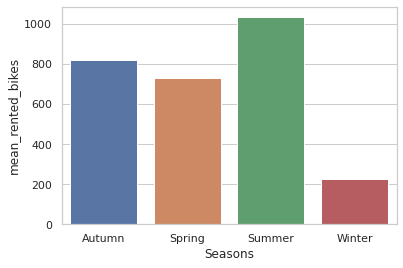

In [68]:
season_data = bike_data.groupby(['Seasons']).agg(mean_rented_bikes=('Rented Bike Count', 'mean'))
season_data = season_data.reset_index()
sns.barplot(x='Seasons',y='mean_rented_bikes',data=season_data)

In [69]:
bike_data.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time of Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,Night
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,Night
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,Night
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,Night
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,Night


<AxesSubplot:xlabel='Seasons', ylabel='mean_rented_bikes'>

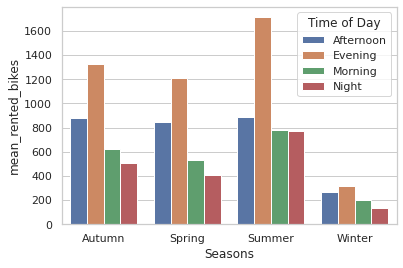

In [70]:
season_data = bike_data.groupby(['Seasons', 'Time of Day']).agg(mean_rented_bikes=('Rented Bike Count', 'mean'))
season_data = season_data.reset_index()
sns.barplot(x='Seasons',y='mean_rented_bikes',hue='Time of Day',data=season_data)

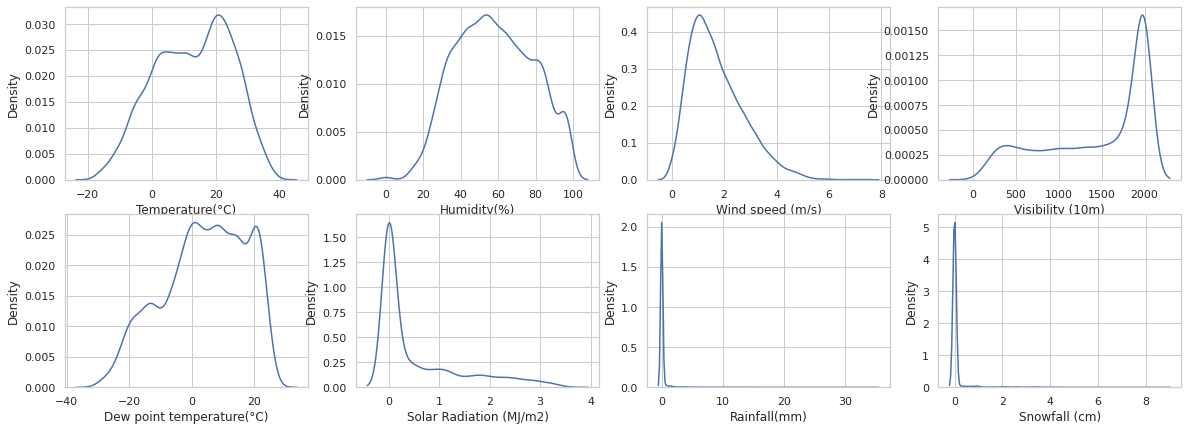

In [71]:
data_columns = ['Temperature(°C)', 'Humidity(%)','Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)',
                'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)']

fig,ax = plt.subplots(2,4,figsize=(20,7))

for i in range(0,2):
    for j in range(0,4):
        sns.kdeplot(ax=ax[i,j],x=bike_data[data_columns[4*i+j]])
        # ax[i,j].plot(bike_data[data_columns[4*i+j]])
        # ax[i,j].set_title(data_columns[4*i+j])

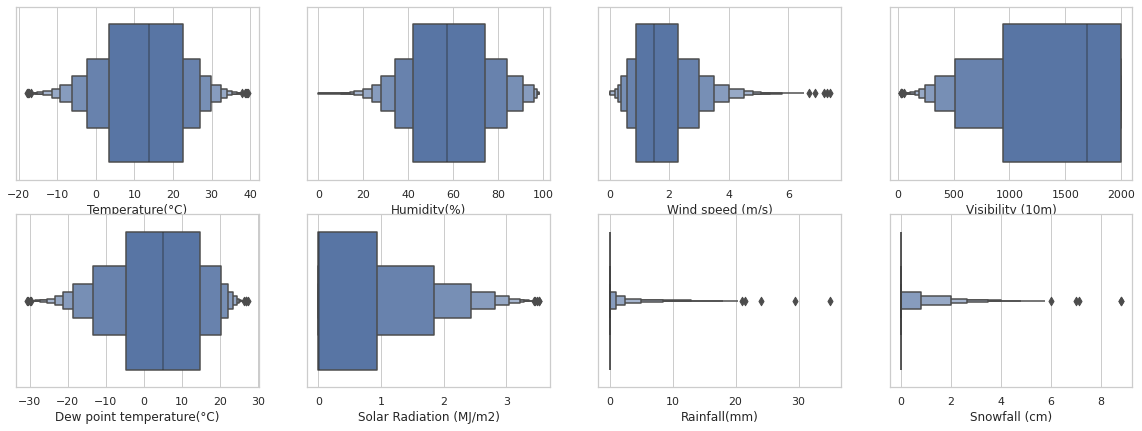

In [72]:
data_columns = ['Temperature(°C)', 'Humidity(%)','Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)',
                'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)']

fig,ax = plt.subplots(2,4,figsize=(20,7))

for i in range(0,2):
    for j in range(0,4):
        sns.boxenplot(ax=ax[i,j],x=bike_data[data_columns[4*i+j]])

<AxesSubplot:xlabel='Temperature(°C)', ylabel='Density'>

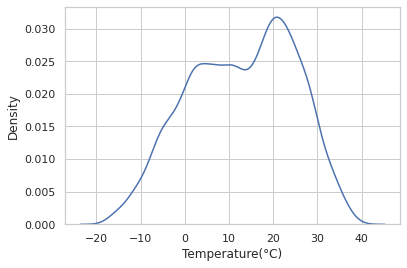

In [73]:
sns.kdeplot(bike_data['Temperature(°C)'])

In [74]:
bike_data['Temperature(°C)'].describe()

count    8760.000000
mean       12.882922
std        11.944825
min       -17.800000
25%         3.500000
50%        13.700000
75%        22.500000
max        39.400000
Name: Temperature(°C), dtype: float64

<AxesSubplot:xlabel='Dew point temperature(°C)', ylabel='Density'>

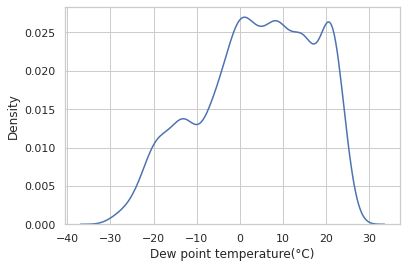

In [75]:
sns.kdeplot(bike_data['Dew point temperature(°C)'])

In [76]:
bike_data['Dew point temperature(°C)'].describe()

count    8760.000000
mean        4.073813
std        13.060369
min       -30.600000
25%        -4.700000
50%         5.100000
75%        14.800000
max        27.200000
Name: Dew point temperature(°C), dtype: float64

<AxesSubplot:xlabel='Visibility (10m)', ylabel='Density'>

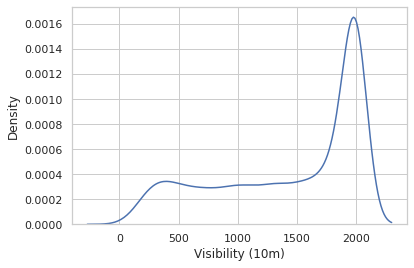

In [77]:
sns.kdeplot(bike_data['Visibility (10m)'])

In [78]:
bike_data['Visibility (10m)'].describe()

count    8760.000000
mean     1436.825799
std       608.298712
min        27.000000
25%       940.000000
50%      1698.000000
75%      2000.000000
max      2000.000000
Name: Visibility (10m), dtype: float64

In [79]:
bike_data['Humidity(%)'].min(),bike_data['Humidity(%)'].max()

(0, 98)

In [80]:
bike_data['Wind speed (m/s)'].min(),bike_data['Wind speed (m/s)'].max()

(0.0, 7.4)

In [81]:
bike_data['Snowfall (cm)'].min(),bike_data['Snowfall (cm)'].max()

(0.0, 8.8)

In [82]:
bike_data['Rainfall(mm)'].min(),bike_data['Rainfall(mm)'].mean(),bike_data['Rainfall(mm)'].max()

(0.0, 0.14868721461187215, 35.0)